# K3 Mountain Sampling via AlphaEarth Embeddings

Two-phase pipeline:
1. **GEE phase** — build a K3-masked composite of AlphaEarth + terrain bands, sample 50 000 candidate points, export to Drive
2. **Local phase** — load the CSV, cluster in embedding space per geographic stratum, select 1 000 medoids

Each step includes a visualisation so you can inspect what's happening.

In [5]:
# Install dependencies (run once)
# !pip install earthengine-api geemap geopandas pyogrio scikit-learn matplotlib

In [3]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import time, sys
from pathlib import Path

In [4]:
# Load Natural Earth country polygons early — needed for both Phase 1 preview map and Phase 2 strata
NE_URL = (
    "https://naciscdn.org/naturalearth/110m/cultural/"
    "ne_110m_admin_0_countries.zip"
)
_ne_cache = Path("data/ne_countries.gpkg")
if _ne_cache.exists():
    countries = gpd.read_file(_ne_cache, engine="pyogrio")
else:
    print("Downloading Natural Earth countries …")
    countries = gpd.read_file(NE_URL, engine="pyogrio")[["CONTINENT", "geometry"]]
    _ne_cache.parent.mkdir(parents=True, exist_ok=True)
    countries.to_file(_ne_cache, driver="GPKG", engine="pyogrio")
world = countries
print(f"Natural Earth loaded: {len(countries)} countries")

Natural Earth loaded: 177 countries


---
## Phase 1 — Google Earth Engine
### 1 · Authentication

In [5]:
PROJECT = "promising-era-496715-j5"

try:
    ee.Initialize(project=PROJECT)
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project=PROJECT)

print("GEE initialised ✓")

GEE initialised ✓


### 2 · Build the K3 composite

We stack three data sources into one multi-band image, then mask to K3 (2 500–3 500 m):
- **AlphaEarth 2023** — 64-dim environmental fingerprint per pixel
- **Elevation** — SRTM 30 m
- **Slope & aspect** — derived from SRTM

In [14]:
SRTM_ID        = "USGS/SRTMGL1_003"
ALPHA_EARTH_IC = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
YEAR           = 2023

srtm   = ee.Image(SRTM_ID).select("elevation")
slope  = ee.Terrain.slope(srtm).rename("slope")
aspect = ee.Terrain.aspect(srtm).rename("aspect")

# Local elevation range within 7 km radius — Kapos K4/K5/K6 criterion
_kernel     = ee.Kernel.circle(7000, "meters")
_elev_max   = srtm.reduceNeighborhood(ee.Reducer.max(), _kernel)
_elev_min   = srtm.reduceNeighborhood(ee.Reducer.min(), _kernel)
local_range = _elev_max.subtract(_elev_min).rename("local_range")

# Kapos (2000) mountain classes
_k1 = srtm.gte(4500)
_k2 = srtm.gte(3500).And(srtm.lt(4500))
_k3 = srtm.gte(2500).And(srtm.lt(3500))
_k4 = srtm.gte(1500).And(srtm.lt(2500)).And(slope.gte(2).Or(local_range.gte(300)))
_k5 = srtm.gte(1000).And(srtm.lt(1500)).And(slope.gte(5).Or(local_range.gte(300)))
_k6 = srtm.gte( 300).And(srtm.lt(1000)).And(local_range.gte(300))

kapos_class = (
    ee.Image(0)
    .where(_k6, 6).where(_k5, 5).where(_k4, 4)
    .where(_k3, 3).where(_k2, 2).where(_k1, 1)
    .rename("kapos_class")
)
mountain_mask = _k1.Or(_k2).Or(_k3).Or(_k4).Or(_k5).Or(_k6)

# AlphaEarth embeddings
alpha_ic = ee.ImageCollection(ALPHA_EARTH_IC).filterDate(f"{YEAR}-01-01", f"{YEAR}-12-31")
n_bands  = len(alpha_ic.first().bandNames().getInfo())
alpha    = alpha_ic.mosaic().rename([f"emb_{i}" for i in range(n_bands)])

composite = (
    alpha
    .addBands(srtm.rename("elevation"))
    .addBands(slope)
    .addBands(aspect)
    .addBands(kapos_class)
    .updateMask(mountain_mask)
)

bands = composite.bandNames().getInfo()
print(f"{len(bands)} bands: {bands[:4]} … {bands[-3:]}")

68 bands: ['emb_0', 'emb_1', 'emb_2', 'emb_3'] … ['slope', 'aspect', 'kapos_class']


### 3 · Visualise K3 mask + one embedding band

In [15]:
# Sample emb_0 at 4 known mountain locations to get actual value range
known_mountains = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([73.5,   38.5])),   # Pamir
    ee.Feature(ee.Geometry.Point([85.5,   27.8])),   # Himalaya
    ee.Feature(ee.Geometry.Point([-70.1, -30.2])),   # Andes
    ee.Feature(ee.Geometry.Point([-116.5, 51.5])),   # Canadian Rockies
])
range_result = alpha.select("emb_0").sampleRegions(
    collection=known_mountains, scale=500, projection="EPSG:4326", geometries=False
).getInfo()
emb0_vals = [f["properties"]["emb_0"] for f in range_result["features"]
             if f["properties"].get("emb_0") is not None]
emb0_min = float(min(emb0_vals))
emb0_max = float(max(emb0_vals))
print(f"emb_0 range across 4 mountain locations: {emb0_min:.4f} – {emb0_max:.4f}")

# K1 (>4500 m) → red … K6 (300–1000 m) → green
KAPOS_VIS = {
    "min": 1, "max": 6,
    "palette": ["#8b0000", "#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"],
}
EMB_VIS = {"min": emb0_min, "max": emb0_max, "palette": ["#d73027", "#ffffbf", "#1a9850"]}

Map = geemap.Map(center=[20, 20], zoom=2)
Map.add_basemap("HYBRID")
Map.addLayer(kapos_class.updateMask(mountain_mask), KAPOS_VIS, "Kapos class (1–6)", True, 0.7)
Map.addLayer(composite.select("emb_0"),             EMB_VIS,   "AlphaEarth emb_0",  True, 0.6)

Map.add_colorbar_branca(
    colors=KAPOS_VIS["palette"],
    vmin=1, vmax=6,
    caption="Kapos class  1=K1 (>4500 m) → 6=K6 (300–1000 m)",
    position="bottomleft",
)
Map.add_colorbar_branca(
    colors=EMB_VIS["palette"],
    vmin=round(emb0_min, 3), vmax=round(emb0_max, 3),
    caption="AlphaEarth emb_0",
    position="bottomright",
)

Map

emb_0 range across 4 mountain locations: -0.0797 – 0.0384


Map(center=[20, 20], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

### 4 · Preview sample (200 pts, instant)

Before committing to the full 2 000 000-point export, draw a small preview to confirm the sampler is hitting K3 pixels globally.

In [16]:
WORLD = ee.Geometry.BBox(-180, -90, 180, 90)

# Sample per region to stay within GEE interactive memory limits
_preview_regions = [
    ee.Geometry.BBox(71,  37,  76,  40),    # Pamir
    ee.Geometry.BBox(83,  26,  88,  30),    # Himalaya
    ee.Geometry.BBox(-73,-32, -68, -28),    # Andes
    ee.Geometry.BBox(-119, 50,-114, 53),    # Canadian Rockies
]
features = []
for r in _preview_regions:
    res = composite.sample(
        region=r, scale=500, projection="EPSG:4326",
        numPixels=40, seed=42, geometries=True, dropNulls=True
    ).getInfo()
    features.extend(res.get("features", []))

preview = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
# lon/lat are in the geometry, not auto-added as properties
preview["longitude"] = preview.geometry.x
preview["latitude"]  = preview.geometry.y

print(f"{len(preview)} preview points")
preview[["elevation", "slope", "aspect", "emb_0", "emb_1"]].describe().round(3)

138 preview points


,elevation,slope,aspect,emb_0,emb_1
count,138.000,138.000,138.000,138.000,138.000
mean,3066.217,16.156,171.508,-0.059,-0.115
std,1503.766,10.192,97.158,0.083,0.123
min,489.000,0.528,2.841,-0.260,-0.284
25%,1801.250,7.472,86.717,-0.118,-0.205
50%,2918.500,15.049,166.704,-0.071,-0.145
75%,4238.250,23.271,247.624,-0.004,-0.075
max,6847.000,47.015,354.134,0.125,0.268


In [17]:
# Reconstruct a GEE FeatureCollection from preview points for geemap display
preview_fc = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([row.longitude, row.latitude]))
    for _, row in preview.iterrows()
])

Map2 = geemap.Map(center=[20, 20], zoom=2)
Map2.add_basemap("HYBRID")
Map2.addLayer(
    kapos_class.updateMask(mountain_mask),
    {"min": 1, "max": 6, "palette": ["#8b0000", "#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]},
    "Kapos class (1–6)", True, 0.5,
)
Map2.addLayer(preview_fc, {"color": "red"}, "Preview points")
Map2

Map(center=[20, 20], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

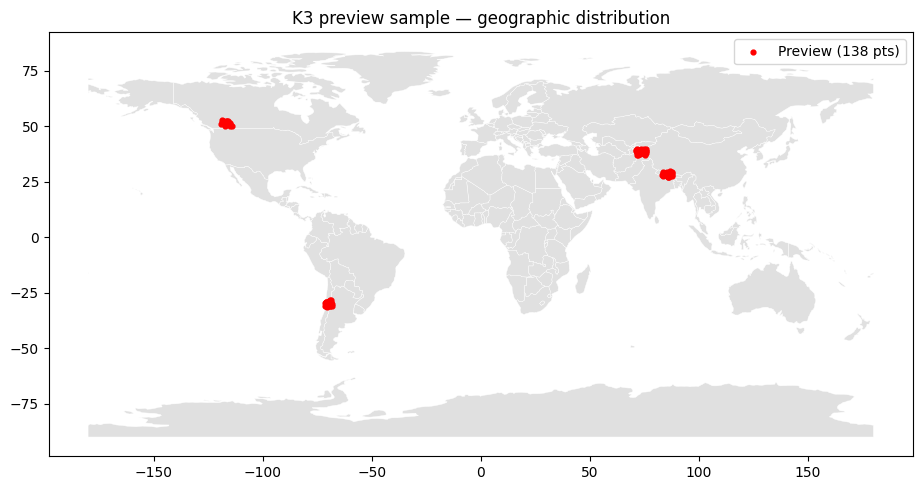

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
countries.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.3)
preview.plot(ax=ax, color="red", markersize=12, zorder=3, label=f"Preview ({len(preview)} pts)")
ax.set_title("K3 preview sample — geographic distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 5 · Full export to Google Drive (2 000 000 pts)

This submits a batch job to GEE. It takes a few minutes to run on their servers.
Monitor at https://code.earthengine.google.com/tasks

When done, download `candidates_k3_raw.csv` from Drive → `data/` folder.

In [ ]:
NUM_CANDIDATES = 500_000   # start here; increase to 1M if the task succeeds
SAMPLE_SCALE   = 500

candidates_fc = composite.sample(
    region=WORLD,
    scale=SAMPLE_SCALE,
    projection="EPSG:4326",
    numPixels=NUM_CANDIDATES,
    seed=42,
    geometries=True,
    dropNulls=True,
    tileScale=4,   # process in smaller tiles to avoid memory overflow
)

# GEE sample() stores coordinates in the geometry, not as named properties.
# Promote them explicitly so they appear as columns in the exported CSV.
def add_lonlat(f):
    coords = f.geometry().coordinates()
    return f.set({"longitude": coords.get(0), "latitude": coords.get(1)})

candidates_fc = candidates_fc.map(add_lonlat)

emb_cols  = [f"emb_{i}" for i in range(n_bands)]
selectors = ["longitude", "latitude", "elevation", "slope", "aspect", "kapos_class"] + emb_cols

task = ee.batch.Export.table.toDrive(
    collection=candidates_fc,
    description="mountain_candidates_500k",
    folder="MountAInWater",
    fileNamePrefix="candidates_kapos_raw",
    fileFormat="CSV",
    selectors=selectors,
)
task.start()
print(f"Task ID : {task.id}")
print("Monitor : https://code.earthengine.google.com/tasks")

In [21]:
# Optional: poll until done (prints status every 30 s)
while True:
    state = task.status()["state"]
    print(f"[{time.strftime('%H:%M:%S')}] {state}")
    if state in ("COMPLETED", "FAILED", "CANCELLED"):
        break
    time.sleep(30)

[13:25:15] COMPLETED


---
## Phase 2 — Local clustering

Once you've downloaded `candidates_k3_raw.csv` to the `data/` folder, continue here.

### 6 · Load & inspect the candidates

In [22]:
CSV_PATH = "data/candidates_k3_raw.csv"

df = pd.read_csv(CSV_PATH)

EMB_COLS       = [c for c in df.columns if c.startswith("emb_")]
ANCILLARY_COLS = ["elevation", "slope", "aspect"]
FEATURE_COLS   = EMB_COLS + ANCILLARY_COLS

df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"{len(df)} candidate points, {len(EMB_COLS)} embedding dims")
df[ANCILLARY_COLS].describe().round(1)

29711 candidate points, 64 embedding dims


,elevation,slope,aspect
count,29711.0,29711.0,29711.0
mean,1586.0,7.9,178.4
std,1256.6,6.9,104.1
min,300.0,0.0,-0.0
25%,690.0,2.6,86.8
50%,1165.0,5.8,180.0
75%,1971.0,11.3,268.8
max,7129.0,55.6,359.7


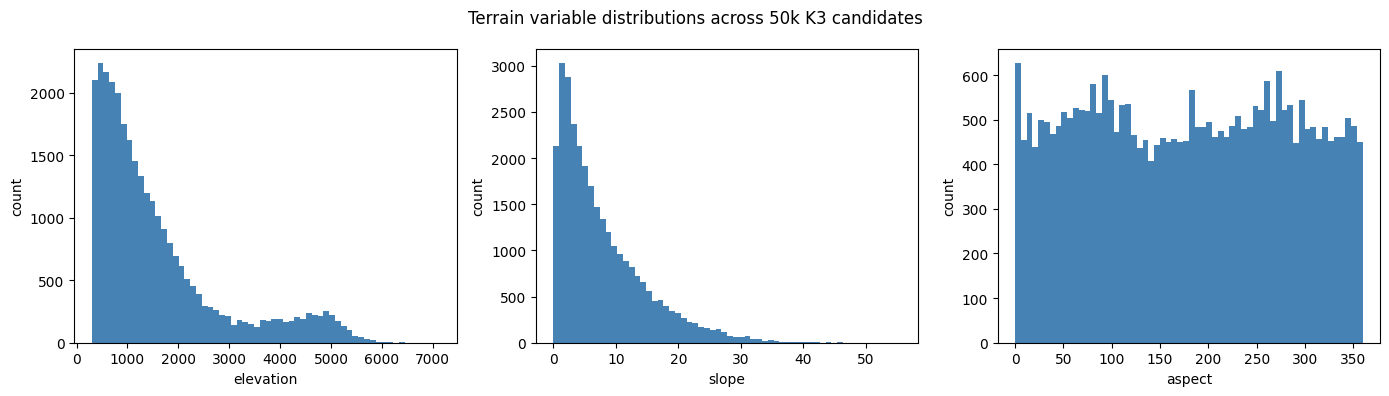

In [23]:
# Distribution of terrain variables
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ANCILLARY_COLS):
    ax.hist(df[col], bins=60, color="steelblue", edgecolor="none")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
plt.suptitle("Terrain variable distributions across 50k K3 candidates")
plt.tight_layout()
plt.show()

ValueError: aspect must be finite and positive 

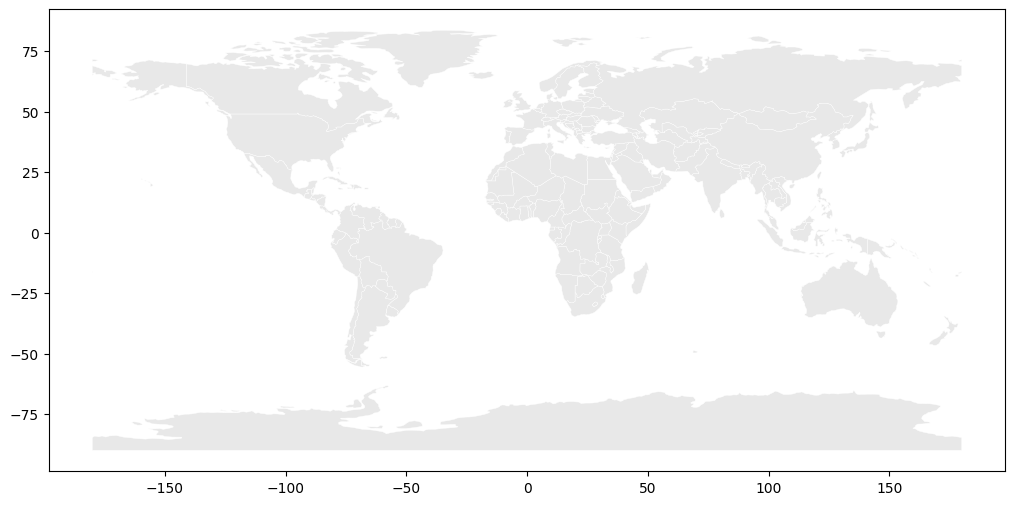

In [25]:
gdf_all = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
)
fig, ax = plt.subplots(figsize=(14, 6))
world.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)
gdf_all.plot(ax=ax, color="#2171b5", markersize=0.5, alpha=0.3)
ax.set_title(f"All {len(df):,} K3 candidate points")
plt.tight_layout()
plt.show()

### 7 · Explore the embedding space (PCA)

Reduce the 64-dim embeddings to 2D to see how the environmental space is structured.

In [ ]:
X = df[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 11), pca.explained_variance_ratio_ * 100, color="steelblue")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("PCA scree plot")

# PC1 vs PC2 coloured by elevation
sc = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df["elevation"], cmap="RdYlGn_r", s=1, alpha=0.3
)
plt.colorbar(sc, ax=axes[1], label="Elevation (m)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("PC1 vs PC2 — coloured by elevation")

plt.tight_layout()
plt.show()
print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.1%}")

### 8 · Assign geographic strata

We cluster **within** each major mountain system to guarantee geographic spread.
Continent labels come from a spatial join against Natural Earth.

In [ ]:
NE_URL = (
    "https://naciscdn.org/naturalearth/110m/cultural/"
    "ne_110m_admin_0_countries.zip"
)
CONTINENT_TO_STRATUM = {
    "Asia":           "Asia_Central",
    "South America":  "South_America",
    "North America":  "North_America",
    "Europe":         "Europe",
    "Africa":         "Africa",
    "Oceania":        "Other",
}

cache = Path("data/ne_countries.gpkg")
if cache.exists():
    countries = gpd.read_file(cache, engine="pyogrio")
else:
    print("Downloading Natural Earth …")
    countries = gpd.read_file(NE_URL, engine="pyogrio")[["CONTINENT", "geometry"]]
    cache.parent.mkdir(parents=True, exist_ok=True)
    countries.to_file(cache, driver="GPKG", engine="pyogrio")

world = countries  # reuse as basemap

pts = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
)
joined  = gpd.sjoin(pts, countries[["CONTINENT", "geometry"]], how="left", predicate="within")
# Deduplicate rows that fall on country borders
joined  = joined[~joined.index.duplicated(keep="first")]
df["stratum"] = joined["CONTINENT"].map(CONTINENT_TO_STRATUM).fillna("Other")

print(df["stratum"].value_counts().to_string())

In [ ]:
# Map candidates coloured by stratum
STRATUM_COLORS = {
    "Asia_Central":  "#e41a1c",
    "South_America": "#377eb8",
    "North_America": "#4daf4a",
    "Europe":        "#984ea3",
    "Africa":        "#ff7f00",
    "Other":         "#a65628",
}

fig, ax = plt.subplots(figsize=(14, 6))
world.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)
for stratum, color in STRATUM_COLORS.items():
    sub = pts[df["stratum"] == stratum]
    sub.plot(ax=ax, color=color, markersize=0.8, alpha=0.5, label=stratum)
ax.legend(markerscale=8, framealpha=0.9)
ax.set_title("Candidate points by stratum")
plt.tight_layout()
plt.show()

### 9 · Stratified k-means → 1 000 medoids

For each stratum, run k-means in the scaled embedding+terrain space and select
the actual data point closest to each cluster centroid (the **medoid**).

In [ ]:
STRATA_QUOTAS = {
    "Asia_Central":  380,
    "South_America": 200,
    "North_America": 120,
    "Europe":        100,
    "Africa":         80,
    "Other":         120,
}
assert sum(STRATA_QUOTAS.values()) == 1000

def cluster_stratum(df_s, quota, seed=42):
    k = min(quota, len(df_s) // 3)
    if k < 1:
        return df_s.head(0)
    X = df_s[FEATURE_COLS].values
    Xs = StandardScaler().fit_transform(X)
    model = (MiniBatchKMeans if len(df_s) >= 10_000 else KMeans)(
        n_clusters=k, random_state=seed, n_init=10
    )
    labels    = model.fit_predict(Xs)
    centroids = model.cluster_centers_
    medoid_idx = [
        np.where(labels == c)[0][np.argmin(
            np.linalg.norm(Xs[labels == c] - centroids[c], axis=1)
        )]
        for c in range(k)
    ]
    out = df_s.iloc[medoid_idx].copy()
    out["cluster_id"] = np.arange(len(out))
    return out

parts = []
for stratum, quota in STRATA_QUOTAS.items():
    sub = df[df["stratum"] == stratum].reset_index(drop=True)
    print(f"  {stratum}: {len(sub):>6} candidates → {quota} clusters", end="  ")
    sel = cluster_stratum(sub, quota)
    sel["stratum"] = stratum
    parts.append(sel)
    print(f"→ {len(sel)} medoids")

selected = pd.concat(parts, ignore_index=True)
selected["cluster_id"] = np.arange(len(selected))
print(f"\nTotal selected: {len(selected)}")

### 10 · Visualise the 1 000 selected points

In [ ]:
gdf_sel = gpd.GeoDataFrame(
    selected,
    geometry=gpd.points_from_xy(selected.longitude, selected.latitude),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(14, 6))
world.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)
for stratum, color in STRATUM_COLORS.items():
    sub = gdf_sel[gdf_sel["stratum"] == stratum]
    sub.plot(ax=ax, color=color, markersize=6, label=f"{stratum} ({len(sub)})", zorder=3)
ax.legend(markerscale=2, framealpha=0.9)
ax.set_title("1 000 selected K3 sample points by stratum")
plt.tight_layout()
plt.show()

In [ ]:
# PCA fit on all candidates, then project both sets into the same space
scaler_pca = StandardScaler().fit(df[FEATURE_COLS].values)
pca2       = PCA(n_components=2).fit(scaler_pca.transform(df[FEATURE_COLS].values))

proj_all = pca2.transform(scaler_pca.transform(df[FEATURE_COLS].values))
proj_sel = pca2.transform(scaler_pca.transform(selected[FEATURE_COLS].values))

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(proj_all[:, 0], proj_all[:, 1], s=0.5, alpha=0.1,
           color="#aec7e8", label="All candidates")
for stratum, color in STRATUM_COLORS.items():
    mask = selected["stratum"].values == stratum
    ax.scatter(proj_sel[mask, 0], proj_sel[mask, 1],
               s=18, color=color, alpha=0.8, label=stratum, zorder=3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA: 1 000 medoids vs all 50k candidates")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

### 11 · Export final GeoJSON

In [ ]:
out_path = Path("data/k3_sample_1000.geojson")
gdf_sel.to_file(out_path, driver="GeoJSON", engine="pyogrio")
print(f"Saved {len(gdf_sel)} points → {out_path}")

# Quick summary
print("\nStratum breakdown:")
print(selected["stratum"].value_counts().to_string())
print(f"\nElevation range : {selected.elevation.min():.0f} – {selected.elevation.max():.0f} m")
print(f"Lat range       : {selected.latitude.min():.1f} – {selected.latitude.max():.1f}°")